### 데이터 불러오기
- 로컬에서 돌아가는 아나콘다 같은 경우에는 경로를 사용할 때 따로 연결을 해줄 필요가 없지만 Colab을 사용할 경우에는 내 경로를 먼저 연결 후에 내 폴더 안에 있는 파일들을 사용할 수 있다.

### 연결방법
1. 드라이브 마운트
  - 내 드라이브 연결
2. 작업 디렉토리(위치)를 사용할 폴더로 변경
  - %cd 사용

In [1]:
# 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# 작업 디렉토리 변경
%cd /content/drive/MyDrive/Colab Notebooks/딥러닝(인공지능사관학교)

/content/drive/MyDrive/Colab Notebooks/딥러닝(인공지능사관학교)


### 압출풀기
- data폴더 안에 있는 small_animal.zip에 대해 압축을 풀도록 명령을 내리기

In [3]:
# !unzip : 내가 압축을 풀고싶은 파일에 대해 압축을 풀 수 있도록 도와주는 기능
# !unzip ./data/animal_small.zip -d ./data/animal

### 데이터 사용
- 압축을 해제한 데이터를 사용하기
- 우리가 사용할 데이터는 이미지 데이터인데 이미지 데이터는 그대로 사용은 할 수가 없고 우리가 사용할 수 있도록 수치화 하여 사용해야 한다.
  - opencv에서 제공하는 이미지 읽어오는 기능을 사용하기
  - tensorflow에서 제공하는 image_dataset_from_directory를 사용하기

In [4]:
# 데이터 다루기 위한 도구 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 이미지를 수치화 하기 위해 폴더에 접근하여 이미지를 읽어올 수 있도록
# 도와주는 도구 불러오기
from tensorflow.keras.utils import image_dataset_from_directory

# 반복문을 사용할 때 진행률 확인하기 위한 도구 불러오기
from tqdm import tqdm

In [5]:
# 이미지 읽어오기(수치화 진행)
train_data = image_dataset_from_directory(
    # 접근 경로 설정 (이미지들이 있는 폴더를 설정)
    directory = './data/animal/animal_small',
    labels = 'inferred', # 폴더이름을 그대로 정답데이터로 사용
    # 다중분류에 맞도록 정답 형태를 지정(원핫인코딩 자동으로 진행)
    label_mode = 'categorical',
    # 색상채널을 설정 (RGB형태의 채널을 선택)
    color_mode = 'rgb',
    # 이미지의 크기를 전부 동일하게 설정(이미지의 크기가 다르면 학습이 불가능)
    image_size = (224,224)
)

Found 2000 files belonging to 4 classes.


In [6]:
# 문제데이터와 정답데이터 분류하기
X_train = []
y_train = []

# tqdm : 반복문을 사용할 때 진행률 확인이 가능하도록 설정
# as_numpy_iterator() : 배열형태로 데이터를 나눠서 사용할 수 있도록 설정
for img, label in tqdm(train_data.as_numpy_iterator()):
  X_train.append(img)
  y_train.append(label)

63it [08:56,  8.52s/it]


In [7]:
# 리스트에 데이터가 담겨있기 때문에 배열형태로 변경하기
# concatenate : 하나씩 하나씩 선택하여 배열형태로 변경하기(연결)
X_train = np.concatenate(X_train)
y_train = np.concatenate(y_train)

In [8]:
# 데이터 크기 확인
print(X_train.shape)
print(y_train.shape)

(2000, 224, 224, 3)
(2000, 4)


In [9]:
y_train[0]

array([0., 1., 0., 0.], dtype=float32)

### MLP층으로 인공신경망 설계
- activation : relu / optimizer : adam

In [10]:
# 라이브러리 불러오기
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, InputLayer

# Sequential : 뼈대생성
# Dense : 중간층, 출력층 쌓을 때 사용
# Flatten : 고차원의 데이터를 1차원으로 펴주는 도구
# InputLayer : 입력층을 쌓을 때 사용하는 도구 중 하나

In [11]:
# 신경망 설계

# 뼈대 생성
mlp_model = Sequential()

# 입력층 쌓기
mlp_model.add(InputLayer(shape=(224,224,3,))) # 3차원의 데이터 입력
# MLP층을 사용하기 위해 Flatten을 이용하여 1차원으로 데이터 변경
mlp_model.add(Flatten())

# 중간층 쌓기
mlp_model.add(Dense(units = 128, activation = 'relu'))
mlp_model.add(Dense(units = 256, activation = 'relu'))
mlp_model.add(Dense(units = 128, activation = 'relu'))

# 출력층 쌓기
mlp_model.add(Dense(units = 4, activation = 'softmax'))

In [12]:
# 학습방법 및 평가방법 설정
mlp_model.compile(
    loss = 'categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [13]:
# 학습진행
mlp_model.fit(
    X_train, y_train, validation_split = 0.2, epochs = 20
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.2481 - loss: 3185.4241 - val_accuracy: 0.2850 - val_loss: 888.7166
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3231 - loss: 526.5576 - val_accuracy: 0.3450 - val_loss: 199.6122
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3381 - loss: 407.5580 - val_accuracy: 0.2975 - val_loss: 386.9629
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3137 - loss: 329.6052 - val_accuracy: 0.3175 - val_loss: 592.1454
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3331 - loss: 183.3631 - val_accuracy: 0.3625 - val_loss: 94.7344
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3613 - loss: 50.0880 - val_accuracy: 0.3225 - val_loss: 35.1841
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3344 - loss: 69.4326 - val_accuracy: 0.2975 - val_loss: 171.3867
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3400 - loss: 120.3693

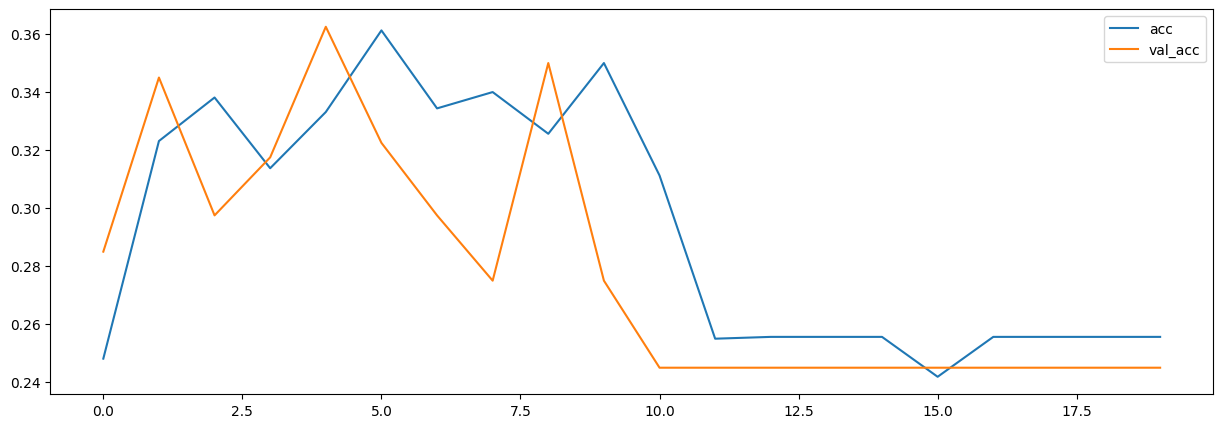

In [14]:
# 결과 시각화
plt.figure(figsize=(15,5))
plt.plot(mlp_model.history.history['accuracy'], label = 'acc')
plt.plot(mlp_model.history.history['val_accuracy'], label = 'val_acc')
plt.legend()
plt.show()

### CNN 모델
- MLP 신경망으로 이미지를 처리할 떄 이미지의 위치 또는 크기에 따라서 매우 민감하게 처리되어 비슷한 크기와 위치를 맞춰줬을 때만 제대로 예측이 가능하다.
- 실제 이미지는 정해진 크기나 위치가 없기 때문에 MLP만으로는 이미지 분석을 잘 할수가 없다.
- 새로운 방안을 고안하여 나온 방법이 바로 CNN층이다.
- CNN층은 이미지 데이터에서 특징값을 추출하여 비슷한 데이터를 골라낼 수 있도록 설정한 방법

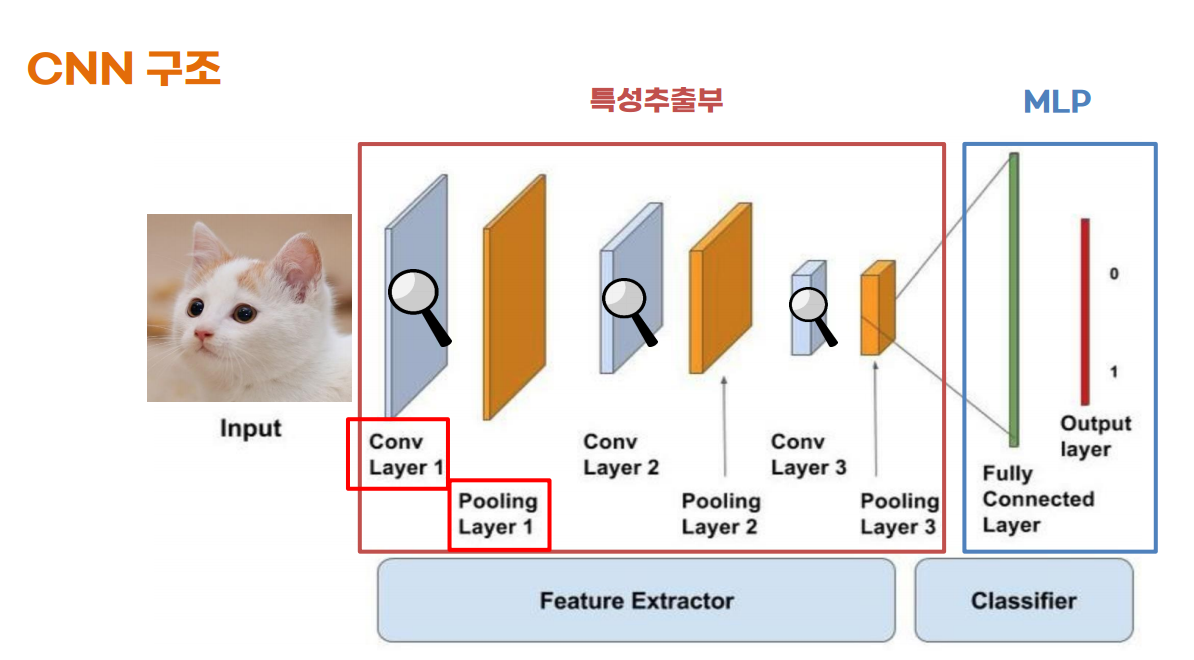

### CNN 원리
- 이미지의 특징을 추출하기 위해 **필터(커널)**을 넣어서 합성곱 계산을 특징을 추출하는 방법
- 이미지 전체에 동일한 연관성으로 처리하는 대신 특정 범위에 한정하여 처리하면 효과적으로 분석할 수 있다는 방법을 고안하여 만들어낸 방법

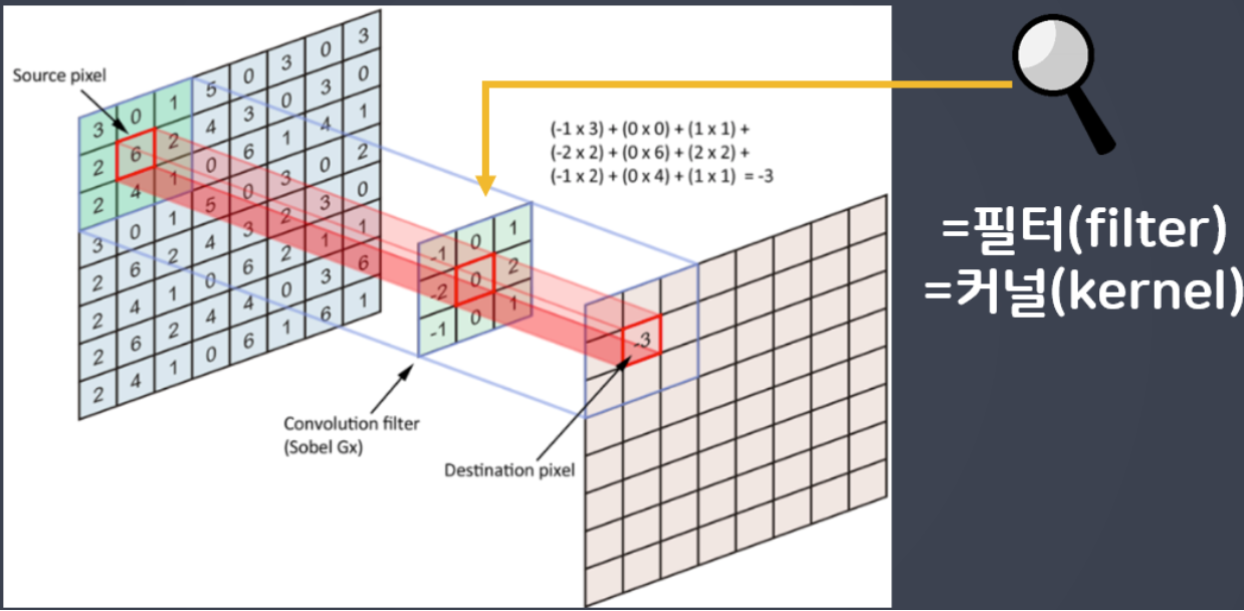

### CNN에서 중요한 용어 정리
- 패딩(Padding)
  - 필터의 크기로 인하여 가장자리 부분의 데이터는 분석이 어렵기 때문에 이를 보안하기 위해 입력데이터의 가장자리에 0을 미리 채워넣어 데이터의 손실을 방지하고 가장자리 데이터도 분석을 하도록 설정한 방법
- 축소 샘플링
  - 데이터의 크기가 너무 크기때문에 연산을 많이 수행하여 시간이 오래걸리며 불필요한 데이터까지 넘길 이유가 없기 때문에 합성곱 결과에서 모든 정보를 전달하지 않고 일부만 샘플링하여 념겨주는 기법
  - 스트라이드
  - 풀링

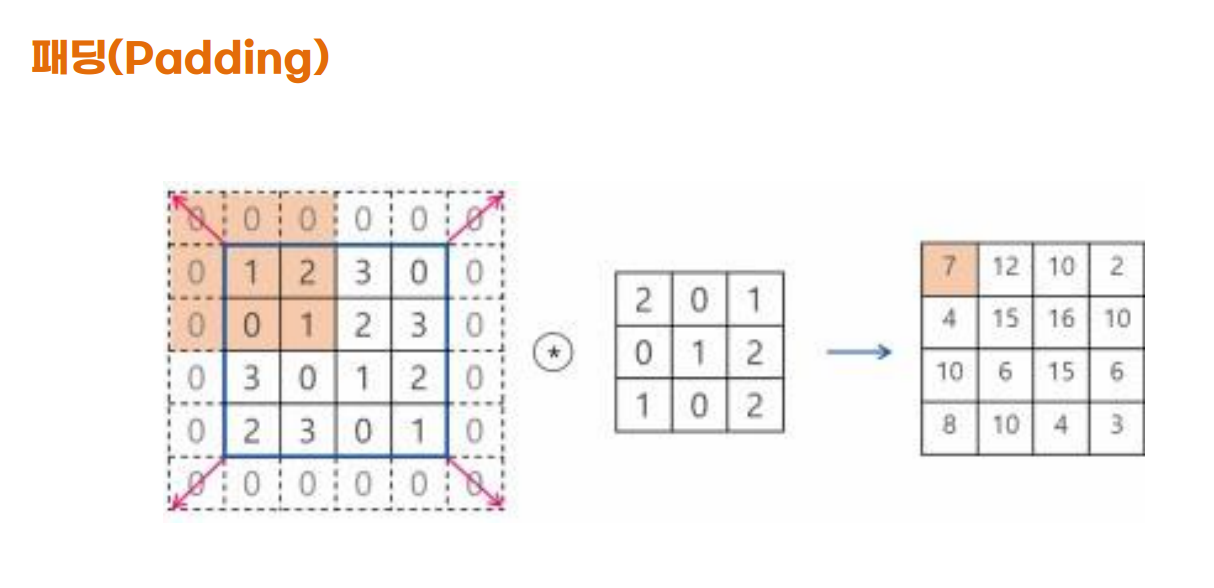

### 축소샘플링
- 스트라이드(Stride)
  - 축소샘플링 방법중 하나로 합성곱 연산을 할 때 모든 데이터를 분석하는 것이 아닌 2~3픽셀씩 옆으로 건너 뛰면서 연산을 하는 방법
  - 이미지의 크기가 너무커서 자원 소모를 방지할 때 사용
  - 너무 많은 픽셀을 이동하면 중요한 데이터를 건너 뛰어버리는 현상이 일어날 수 있기 때문에 적당한 픽섹을 이동해야 한다.
- 풀링(Pooling)
  - 합성곱 연산의 결과를 다음층으로 넘길 때 모든 데이터를 넘기는 것이 아니라 대표값(가장 큰값 또는 평균값)을 넘기는 방법
  - 대표정보를 넘기기 때문에 불필요한 데이터는 제거하고 중요한 데이터만 남겨서 활용할 수 있어 효율적으로 학습할 수 있다는 특징이 있음

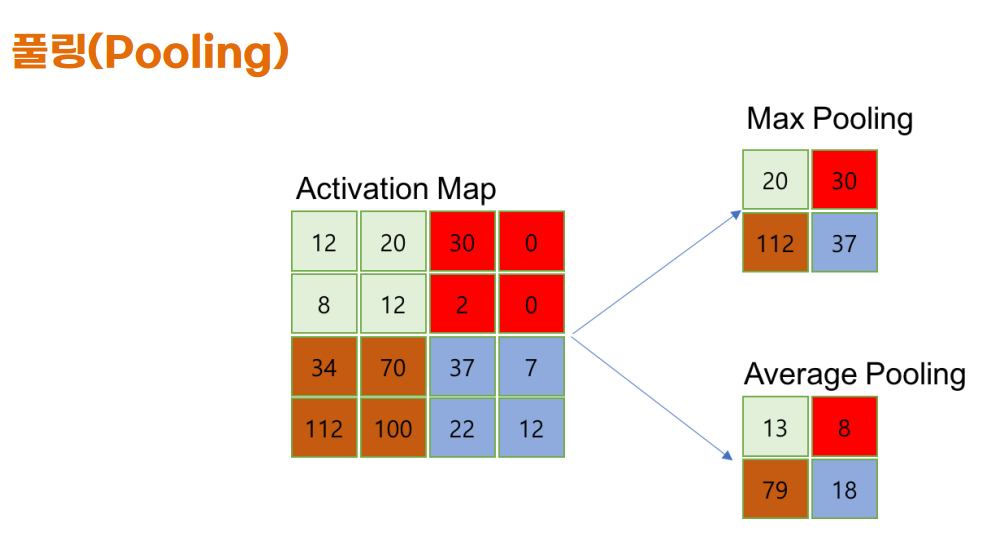

### CNN 신경망 설계

In [15]:
# CNN층을 쌓기 위한 도구 불러오기
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D

# Conv2D : 이미지의 특징을 잡아내도록 도와주는 층(이미지 커널 계산 진행)
# MaxPooling2D : 불필요한 데이터를 삭제하여 특징만 전달하도록 하는 풀링층

# 2D : 2차원의 합성곱 계산 -> 연산이 빠르다
# 3D : 3차원의 합성곱 계산 -> 연산이 느리지만 상세한 분석이 가능

In [16]:
# 신경망 설계
# CNN층은 결과출력을 하는 것이 아니라 특성을 추출해주는 역활이기 때문에
# MLP층과 혼합하여 사용해야 한다.
# 뼈대생성 -> 입력층 -> CNN층 -> MLP층

# 뼈대 생성
cnn_model = Sequential()

# 입력층 쌓기
cnn_model.add(InputLayer(shape = (224,224,3,)))

# CNN층 쌓기
cnn_model.add(Conv2D(
    # 필터(커널)의 개수 설정
    filters = 64,
    # 필터의 크기 조절 (무조건 홀수로 사용)
    # 일반적으로 (3,3) or (5,5) 사용
    kernel_size = (3,3),
    activation = 'relu'
))
# Pooling 층 쌓기
cnn_model.add(MaxPooling2D())

cnn_model.add(Conv2D(
    filters = 128,
    kernel_size = (3,3),
    activation = 'relu'
))
cnn_model.add(MaxPooling2D())

cnn_model.add(Conv2D(
    filters = 64,
    kernel_size = (3,3),
    activation='relu'
))
cnn_model.add(MaxPooling2D())

# MLP층 쌓기
# 특성추출부에 추출한 특성값을 이용하여 어떤 동물의 이미지인지를 판단하는
# MLP층을 쌓기

# MLP층은 1차원의 데이터만 사용 가능하기 때문에 Flatten층을 이용하여
# 1차원으로 데이터를 펴주기
cnn_model.add(Flatten())

# 중간층 쌓기(위의 MLP모델과 동일하게 층 설정)
cnn_model.add(Dense(units = 128, activation = 'relu'))
cnn_model.add(Dense(units = 256, activation = 'relu'))
cnn_model.add(Dense(units = 128, activation = 'relu'))

# 출력층 쌓기
cnn_model.add(Dense(units = 4, activation = 'softmax'))

In [17]:
# 학습방법 및 평가방법 설정
cnn_model.compile(
    loss = 'categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [18]:
# cnn모델 학습
cnn_model.fit(
    X_train, y_train,
    validation_split = 0.2,
    epochs = 20
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 319ms/step - accuracy: 0.2700 - loss: 7.7563 - val_accuracy: 0.2500 - val_loss: 1.3858
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.3506 - loss: 1.3420 - val_accuracy: 0.2525 - val_loss: 1.3966
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.4275 - loss: 1.2271 - val_accuracy: 0.2850 - val_loss: 1.4380
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.5431 - loss: 1.0134 - val_accuracy: 0.2875 - val_loss: 1.9938
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.6762 - loss: 0.7482 - val_accuracy: 0.3075 - val_loss: 2.6398
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.7713 - loss: 0.5699 - val_accuracy: 0.2900 - val_loss: 3.9567
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.8112 - loss: 0.4793 - val_accuracy: 0.2625 - val_loss: 3.6116
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.8712 - loss: 0.3442 - val_accuracy: 0

### 결과 시각화

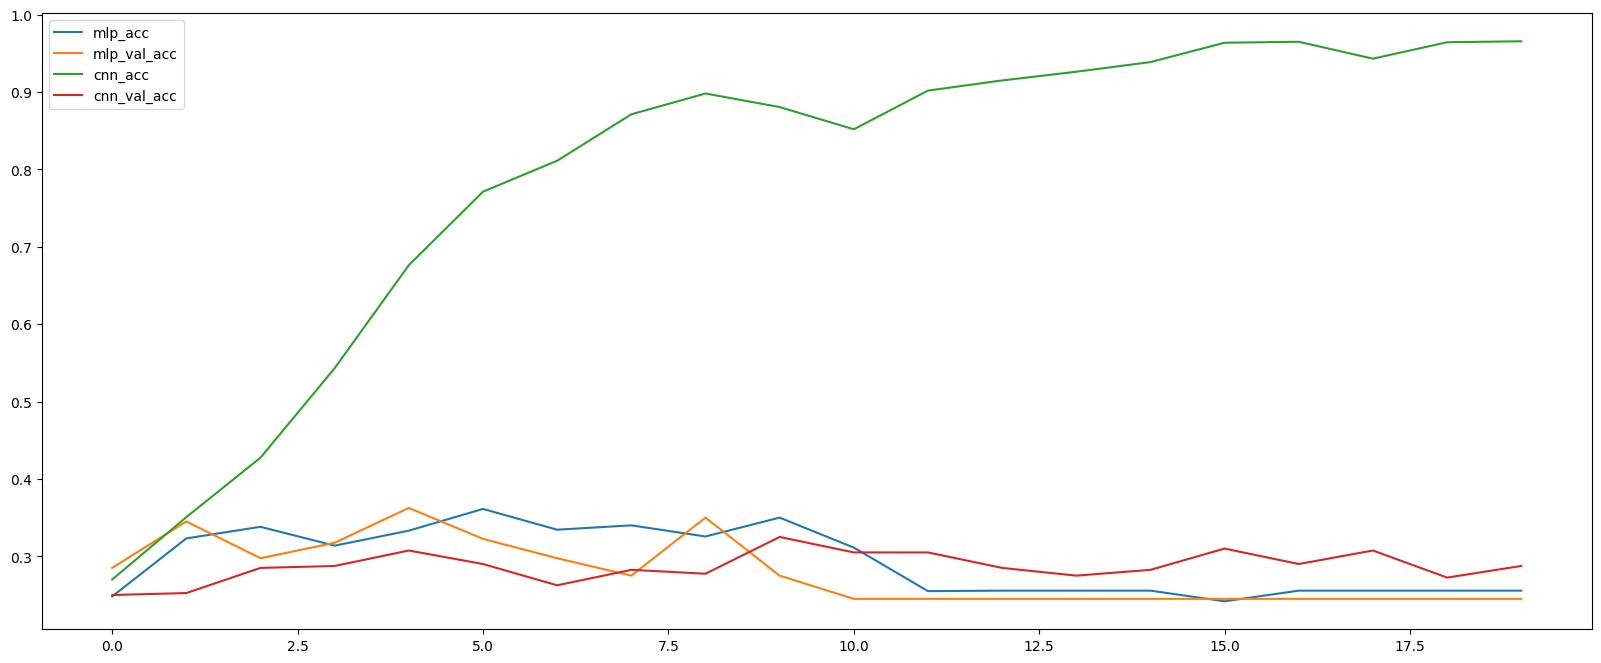

In [21]:
plt.figure(figsize=(20,8))

# MLP 모델 출력
plt.plot(mlp_model.history.history['accuracy'], label='mlp_acc')
plt.plot(mlp_model.history.history['val_accuracy'], label='mlp_val_acc')

# CNN 모델 출력
plt.plot(cnn_model.history.history['accuracy'], label='cnn_acc')
plt.plot(cnn_model.history.history['val_accuracy'], label='cnn_val_acc')

plt.legend()
plt.show()

### 결과 확인
- 일반적인 MLP를 사용할 때는 성능이 매우 낮았다. 하지만 CNN층을 사용해보니 성능이 향상된 것을 알 수 있음
- 이미지 데이터 같은 경우에는 비슷한 형태나 방향 각도 위치 등을 맞추기 어렵기 때문에 CNN층과 같이 특징(특성)을 추출할 수 있는 Layer를 추가하는 것이 성능향상에 도움이 됨
- 현제 데이터의 양이 많지 않으며 층을 쌓을 때 사용법 위주로 쌓았기 때문에 과적합이 일어난 것을 알 수 있음
- 앞으로 해야할 일은 과적합을 방지하기 위해 데이터를 증강하거나 층을 좀 더 상세히 쌓아 과적합을 방지해야 할 것 같음
- 또한 전처리에 대해서 자세히 한 것은 아니기 때문에 전처리를 하는 것이 도움이 될 것으로 판단

### 스케일링
- 데이터 전처리 방법 중 하나로 데이터의 범위값을 일정하게 변경하여 데이터의 범위에 따라서 해당 컬럼이 중요하게 여겨지는 것을 방지하는 전처리 기법